BIOSEÑALES

PRACTICA #3 - PARTE 1

Nombres: Juan Sebastian Daza Betancourt - Juan Jose Lopez Cuadros

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller

In [ ]:
archivo = "signals.mat"

data = scipy.io.loadmat(archivo)

print(data.keys())

#1. Implementacion de funciones

def calcular_rms(senal):

    senal = np.array(senal)
    cuadrado = senal ** 2
    promedio_c = np.mean(cuadrado)
    rms = np.sqrt(promedio_c)

    return rms

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


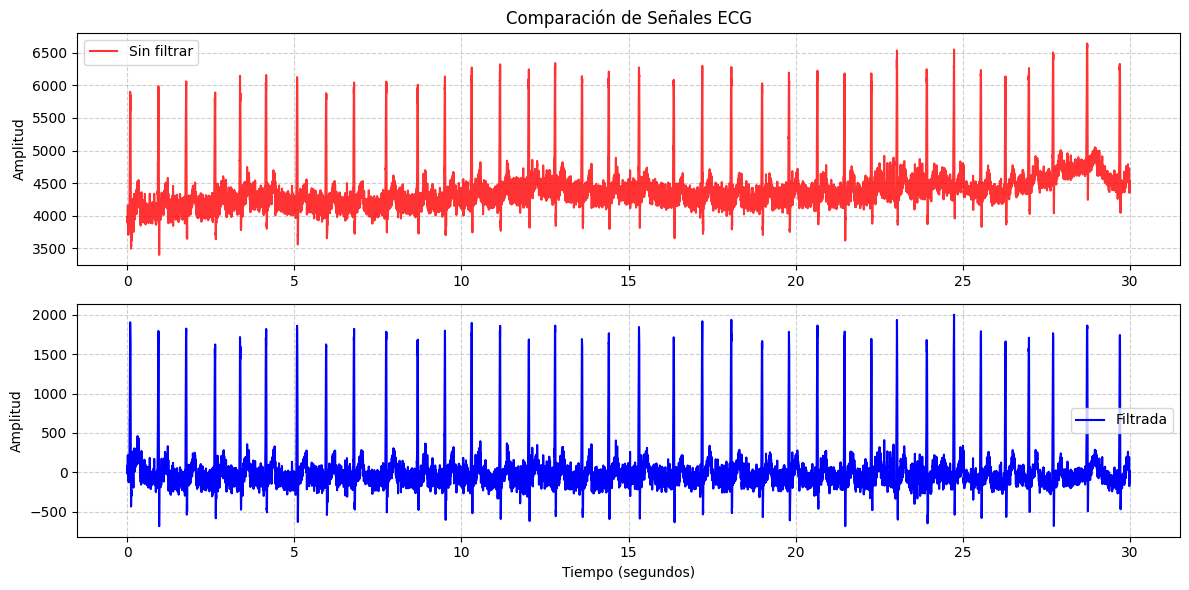

In [ ]:
#2. Analisis estadistico de ECG

#a)

ECG_n = data['ECG_asRecording'].flatten()
N1 = len(ECG_n)
n1 = np.arange(N1) / 1024

ECG_f = data['ECG_filtered'].flatten()
N2 = len(ECG_f)
n2 = np.arange(N2) / 1024

#b)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(n1, ECG_n, color='red', alpha=0.8, label='Sin filtrar')
plt.title('Comparación de Señales ECG')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(n2, ECG_f, color='blue', label='Filtrada')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Es posible identificar que la señal sin filtrar presenta ruido de alta frecuencia (se ve un mayor numero de oscilaciones), ademas de su inestabilidad para mantenerse en un rango de amplitud. Lo anterior es posible que lo cause la interferencia electrica, el movimiento y respiracion del paciente.

Las frecuencias de interes para un ECG son de 0.05 Hz a 100 Hz. Por lo tanto, necesito un filtro pasa-banda que detenga las frecuencias menores a 0.05 (de respiracion usuamente), y las frecuencias mayores a 100 Hz. Ademas de un filtro Notch que elimine la interferencia de la red electrica de 60 Hz.

---

SEÑAL SIN FILTRAR
Promedio: 4154.011122279821
Valor RMS:4164.736145037222
Varianza:89218.75375503382
Desviación Estándar:298.6950849194439
SEÑAL FILTRADA
Promedio:6.981423007735122
Valor RMS:291.5240533852265
Varianza:84937.53343493947
Desviación Estándar:291.44044577741687


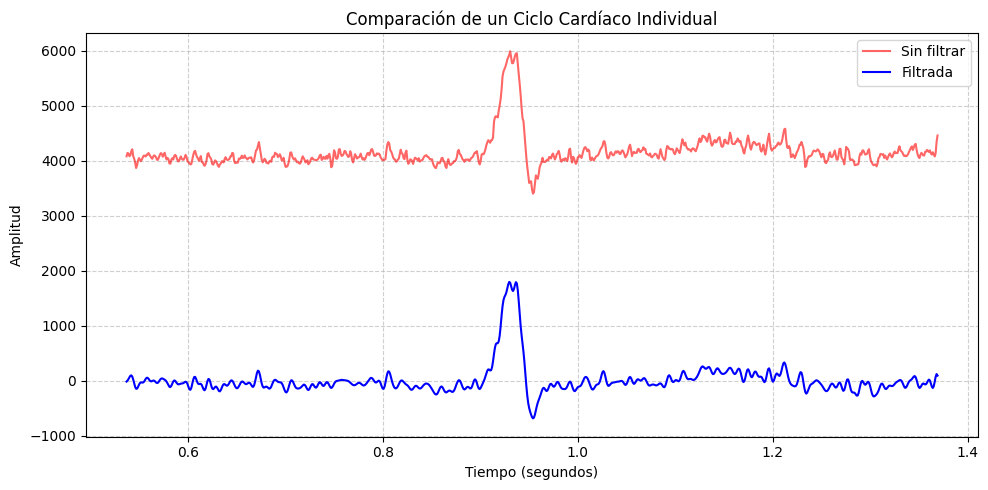

In [ ]:
#c)

inicio = 550
fin = 853 + 550

ciclo_n = ECG_n[inicio:fin]
t_ciclo = n1[inicio:fin]

promedio_n = np.mean(ciclo_n)
rms_n = calcular_rms(ciclo_n)
varianza_n = np.var(ciclo_n)
std_n = np.std(ciclo_n)

print("SEÑAL SIN FILTRAR")
print(f"Promedio: {promedio_n}")
print(f"Valor RMS:{rms_n}")
print(f"Varianza:{varianza_n}")
print(f"Desviación Estándar:{std_n}")

#d)

ciclo_f = ECG_f[inicio:fin]
t_ciclo = n1[inicio:fin]

promedio_f = np.mean(ciclo_f)
rms_f = calcular_rms(ciclo_f)
varianza_f = np.var(ciclo_f)
std_f = np.std(ciclo_f)

print("SEÑAL FILTRADA")
print(f"Promedio:{promedio_f}")
print(f"Valor RMS:{rms_f}")
print(f"Varianza:{varianza_f}")
print(f"Desviación Estándar:{std_f}")


plt.figure(figsize=(10, 5))
plt.plot(t_ciclo, ciclo_n, color='red', alpha=0.6, label='Sin filtrar')
plt.plot(t_ciclo, ciclo_f, color='blue', label='Filtrada')
plt.title('Comparación de un Ciclo Cardíaco Individual')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Vemos que el promedio de la señal filtrada es mucho mas cercana a 0. Esto porque la señal original tiene un voltaje de offset y sube la señal hasta casi 4000.

El RMS lo podemos interpretar como la energia de la señal. En la señal original es mucho mas alto porque se le suma la energia de todas las interferencias, de movimiento, electricas, etc. Despues del filtro, queda unicamente la derivada de la actividad cardiaca.

La varianza y desviacion estandar son bastante similares en ambos casos, y es que, a pesar del ruido en la señal original, ambas van a mantener picos y valles muy similares, alejandose del promedio de manera propocional.


---


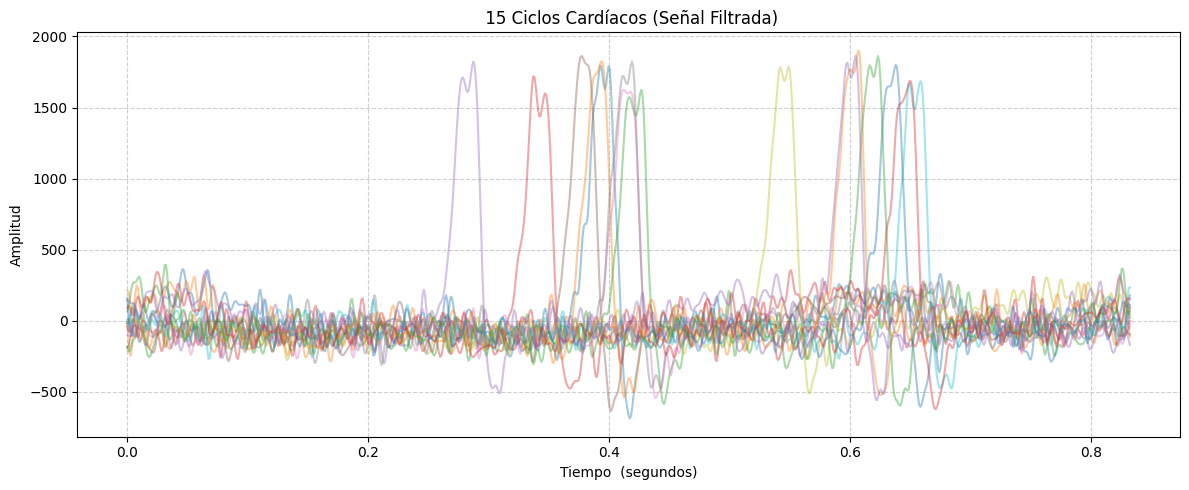

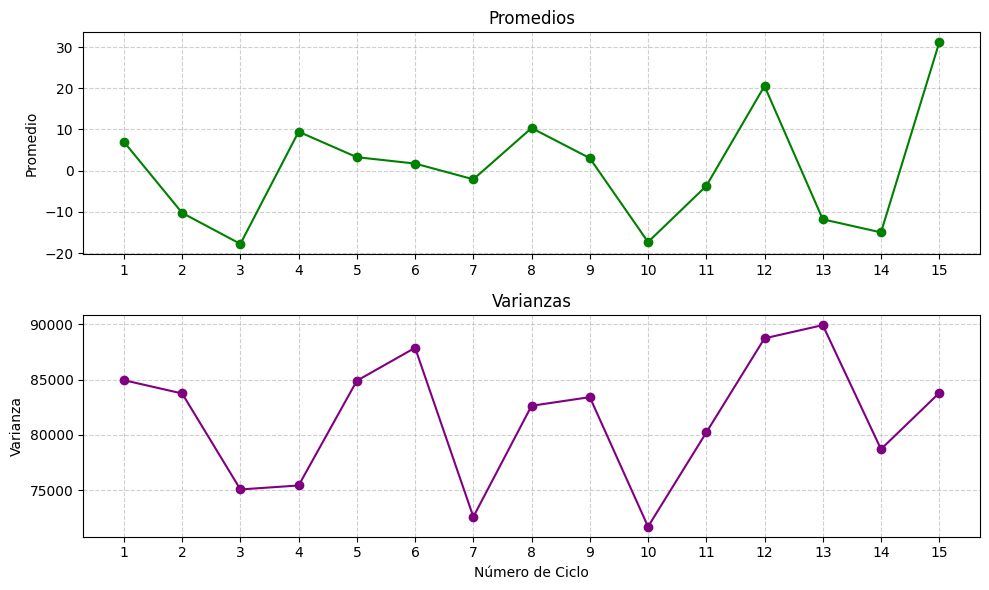

Estadisticos
Ciclo 01 | Promedio: 6.981423 | Varianza: 84937.533435
Ciclo 02 | Promedio: -10.268368 | Varianza: 83739.646350
Ciclo 03 | Promedio: -17.796329 | Varianza: 75088.282276
Ciclo 04 | Promedio: 9.442637 | Varianza: 75445.053818
Ciclo 05 | Promedio: 3.257625 | Varianza: 84890.124207
Ciclo 06 | Promedio: 1.709813 | Varianza: 87859.226948
Ciclo 07 | Promedio: -2.110814 | Varianza: 72618.945743
Ciclo 08 | Promedio: 10.336602 | Varianza: 82631.598185
Ciclo 09 | Promedio: 3.025498 | Varianza: 83409.029066
Ciclo 10 | Promedio: -17.337375 | Varianza: 71733.933737
Ciclo 11 | Promedio: -3.724502 | Varianza: 80222.577671
Ciclo 12 | Promedio: 20.540086 | Varianza: 88711.688050
Ciclo 13 | Promedio: -11.813740 | Varianza: 89901.964657
Ciclo 14 | Promedio: -15.000780 | Varianza: 78719.313438
Ciclo 15 | Promedio: 31.120213 | Varianza: 83784.343419


In [ ]:
#e)

promedios = []
varianzas = []

plt.figure(figsize=(12, 5))

num_ciclos = 15
longitud_ciclo = 853
inicio_actual = 550

for i in range(num_ciclos):
    fin_actual = inicio_actual + longitud_ciclo
    ciclo = ECG_f[inicio_actual:fin_actual]

    prom = np.mean(ciclo)
    var = np.var(ciclo)
    promedios.append(prom)
    varianzas.append(var)

    t= np.arange(longitud_ciclo) / 1024
    plt.plot(t, ciclo, alpha=0.4)
    inicio_actual = fin_actual

plt.title(' 15 Ciclos Cardíacos (Señal Filtrada)')
plt.xlabel('Tiempo  (segundos)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(range(1, num_ciclos + 1), promedios, marker='o', color='green')
ax1.set_title('Promedios')
ax1.set_ylabel('Promedio')
ax1.set_xticks(range(1, num_ciclos + 1))
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(range(1, num_ciclos + 1), varianzas, marker='o', color='purple')
ax2.set_title('Varianzas')
ax2.set_xlabel('Número de Ciclo')
ax2.set_ylabel('Varianza')
ax2.set_xticks(range(1, num_ciclos + 1))
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Estadisticos")
for i in range(num_ciclos):
    print(f"Ciclo {i+1:02d} | Promedio: {promedios[i]:.6f} | Varianza: {varianzas[i]:.6f}")

Estamos tomando un rango de tiempo muy corto (unicamente 15 ciclos). Sabemos que biologicamente la señal cardiaca al ser un sistema dinamico no es estacionario, lo podemos evidenciar en el desface del complejo QRS de la primera grafica.

Durante los 15 ciclos, el promedio no está cambiando significativamente, entendiendo que se trata de una señal de milivoltios, 45 mV de diferencia de una señal a otra no tiene implicaciones mayores. Ademas, vemos que las varianzas se mantienen cercanas a 80000, estas no se disparan aumentando o disminuyendo drasticamente.

Entonces, a pesar de que sabemos que la señal cardiaca no es estacionaria, al analizar matematicamente por cortos periodos, la poca diferencia de los promedios y varianzas nos permiten concluir que al trabajar la señal de esta manera, la podemos tratar como ESTACIONARIA.

---



In [ ]:
#f)

def comparacion(ciclo_a, ciclo_b, nom_a, nom_b):
    print(f"\nComparando {nom_a} vs {nom_b}")

    # Shapiro-Wilk
    _, p_norm_a = stats.shapiro(ciclo_a)
    _, p_norm_b = stats.shapiro(ciclo_b)

    # 2. Prueba de Homocedasticidad (Levene)
    _, p_levene = stats.levene(ciclo_a, ciclo_b)

    print(f"Valor p Normalidad: {nom_a}={p_norm_a:.4f}, {nom_b}={p_norm_b:.4f}")
    print(f"Valor p Homocedasticidad (Levene): {p_levene:.4f}")

    # Elección de la prueba
    if p_norm_a > 0.05 and p_norm_b > 0.05 and p_levene > 0.05:
        t_stat, p_val = stats.ttest_ind(ciclo_a, ciclo_b)
        print(f"Prueba T-Student: Valor p = {p_val:.4f}")
    else:
        u_stat, p_val = stats.mannwhitneyu(ciclo_a, ciclo_b)
        print(f"Prueba U de Mann-Whitney: Valor p = {p_val:.4f}")

    if p_val < 0.05:
        print("Existen diferencias estadísticas significativas.")
    else:
        print("No existen diferencias estadísticas.")

ci = 853
nci = 11
ciclos = []
for i in range(nci):
    inici = inicio + i * ci
    fin = inici + ci
    if fin <= len(ECG_f):
        ciclos.append(ECG_f[inici:fin])
    else:
        print(f"Error")
        break

# dos comparaciones aleatorias
comparacion(ciclos[0], ciclos[1], "Ciclo 1", "Ciclo 2")
comparacion(ciclos[4], ciclos[10], "Ciclo 5", "Ciclo 11")

#g)

print("\nPRUEBA DE DICKEY-FULLER\n ")
resultado_adf = adfuller(ECG_f)
print(f'Estadístico ADF: {resultado_adf[0]:.4f}')
print(f'p-valor: {resultado_adf[1]:.4f}')

if resultado_adf[1] < 0.05:
    print("La prueba rechaza la hipótesis nula: La señal es ESTACIONARIA.")
else:
    print("La prueba NO rechaza la hipótesis nula: La señal NO es estacionaria.")


Comparando Ciclo 1 vs Ciclo 2
Valor p Normalidad: Ciclo 1=0.0000, Ciclo 2=0.0000
Valor p Homocedasticidad (Levene): 0.9803
Prueba U de Mann-Whitney: Valor p = 0.0010
Existen diferencias estadísticas significativas.

Comparando Ciclo 5 vs Ciclo 11
Valor p Normalidad: Ciclo 5=0.0000, Ciclo 11=0.0000
Valor p Homocedasticidad (Levene): 0.8849
Prueba U de Mann-Whitney: Valor p = 0.2471
No existen diferencias estadísticas.

PRUEBA DE DICKEY-FULLER
 
Estadístico ADF: -24.1341
p-valor: 0.0000
La prueba rechaza la hipótesis nula: La señal es ESTACIONARIA.


 La prueba de normalidad y homocedasticidad con un resultado de p < 0.05 nos confirma que los ciclos no siguen una distribución normal. Esto se espera de un ciclo ECG debido a su naturaleza ya que tiene una línea base plana y un pico muy prominente, lo que crea un sesgo enorme. Homocedasticidad p > 0.05: Al obtener valores como 0.98 y 0.88, observamos una varianza constante entre ciclos.

 Debido a que el ECG tiene naturaleza no parametrica, las pruebas de normalidad casi siempre fallaan. debido a esto, la prueba U de Mann Whitney es la herramienta estadísticamente correcta para comparar ciclos.

 El valor p en la prueba de Levene demuestra que el proceso de filtrado fue exitoso en estabilizar la energía de la señal, o sea, su varianza, permitiendo comparaciones estadísticas válidas.

 Por ultimo, de forma global la señal es estacionaria según la pruebaa de Dickey fuller porque el filtro eliminó el desplazamiento, haciendo que la señal sea predecible en su promedio a largo plazo.